11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Training Model with Sigmoid ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.1047 - loss: 2.3157 - val_accuracy: 0.1060 - val_loss: 2.3255
Epoch 2/10
 29/750 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0880 - loss: 2.3148

/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1093 - loss: 2.3076 - val_accuracy: 0.0956 - val_loss: 2.2987
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1434 - loss: 2.2823 - val_accuracy: 0.2817 - val_loss: 2.2223
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3630 - loss: 1.7546 - val_accuracy: 0.4541 - val_loss: 1.3545
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 1.1312 - val_accuracy: 0.7460 - val_loss: 0.8346
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7753 - loss: 0.7319 - val_accuracy: 0.8166 - val_loss: 0.6180
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8260 - loss: 0.6010 - val_accuracy: 0.8559 - val_loss: 0.5149
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8548 - loss: 0.5202 - val_accuracy: 0.8602 - val_loss: 0.4869
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8745 - loss: 0.4620 - val_accuracy: 0.8899 - val_

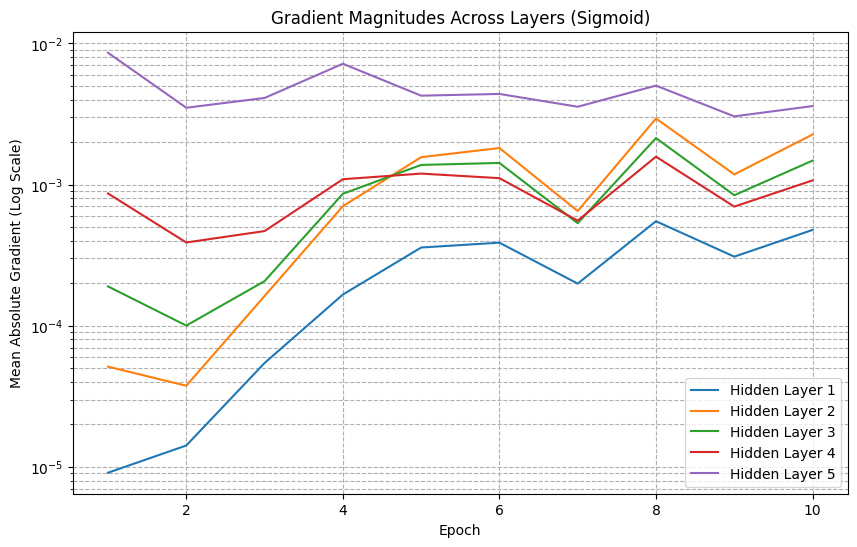

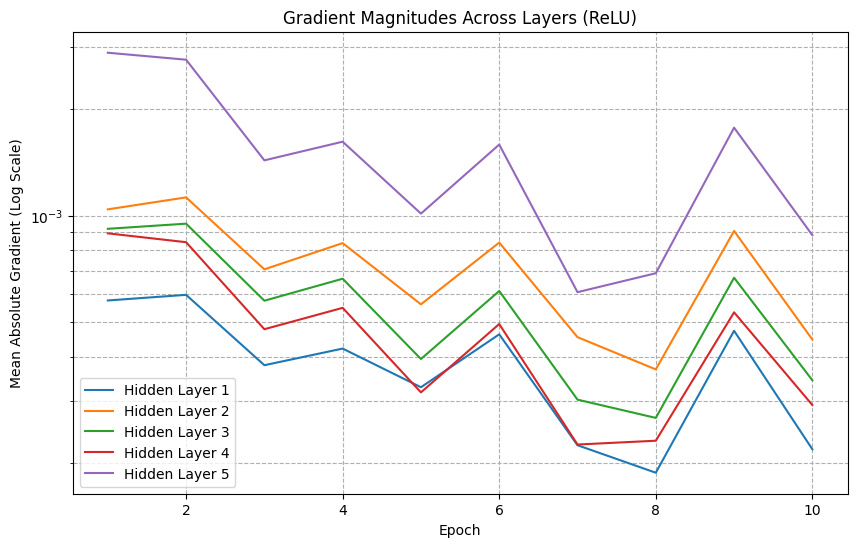

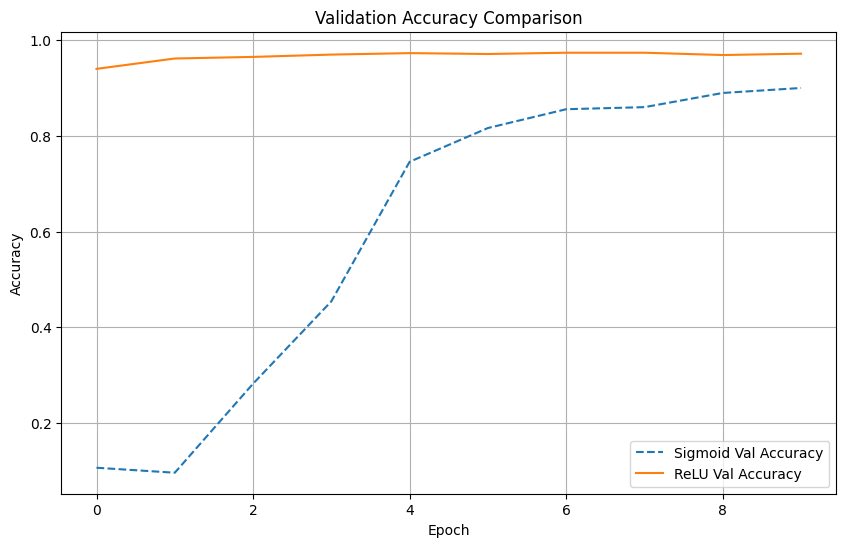

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


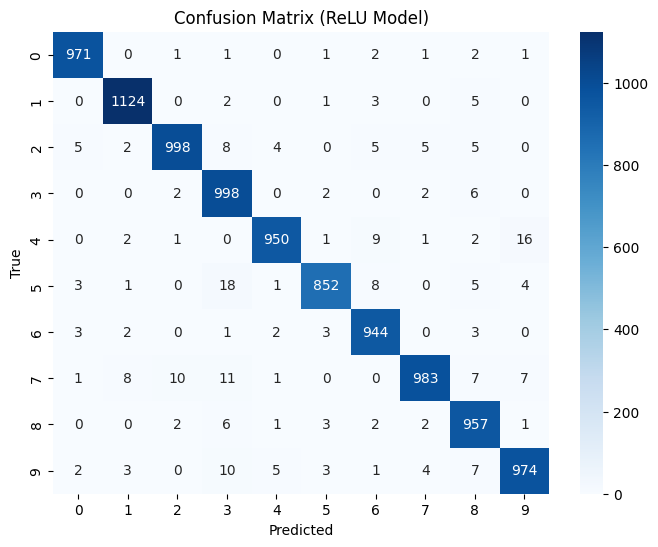

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Load and Preprocess Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

# 2. Custom Callback to Track Gradients
class GradientTracker(tf.keras.callbacks.Callback):
    def __init__(self, x_sample, y_sample):
        super().__init__()
        self.x_sample = tf.convert_to_tensor(x_sample, dtype=tf.float32)
        self.y_sample = tf.convert_to_tensor(y_sample, dtype=tf.int32)
        self.gradient_logs = []

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            predictions = self.model(self.x_sample, training=True)
            loss = self.model.compiled_loss(self.y_sample, predictions)

        # Calculate gradients
        gradients = tape.gradient(loss, self.model.trainable_weights)

        # Extract mean absolute gradient for the weights (excluding biases)
        layer_grads = []
        for grad, weight in zip(gradients, self.model.trainable_weights):
            if 'kernel' in weight.name:
                layer_grads.append(np.mean(np.abs(grad.numpy())))

        self.gradient_logs.append(layer_grads)

# 3. Model Building Function
def build_deep_model(activation_func):
    model = models.Sequential([
        layers.Dense(128, activation=activation_func, input_shape=(784,), name="Layer_1"),
        layers.Dense(128, activation=activation_func, name="Layer_2"),
        layers.Dense(128, activation=activation_func, name="Layer_3"),
        layers.Dense(128, activation=activation_func, name="Layer_4"),
        layers.Dense(10, activation="softmax", name="Output_Layer")
    ])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# 4. Train Models
print("--- Training Model with Sigmoid ---")
sigmoid_model = build_deep_model("sigmoid")
grad_tracker_sigmoid = GradientTracker(x_train[:1000], y_train[:1000])
hist_sig = sigmoid_model.fit(x_train, y_train, epochs=10, batch_size=64,
                             validation_split=0.2, callbacks=[grad_tracker_sigmoid], verbose=1)

print("\n--- Training Model with ReLU ---")
relu_model = build_deep_model("relu")
grad_tracker_relu = GradientTracker(x_train[:1000], y_train[:1000])
hist_relu = relu_model.fit(x_train, y_train, epochs=10, batch_size=64,
                           validation_split=0.2, callbacks=[grad_tracker_relu], verbose=1)

# 5. Evaluate and Print Results
test_loss_sig, test_acc_sig = sigmoid_model.evaluate(x_test, y_test, verbose=0)
test_loss_relu, test_acc_relu = relu_model.evaluate(x_test, y_test, verbose=0)

print("\n--- Final Results ---")
print(f"Sigmoid Test Accuracy: {test_acc_sig:.4f}")
print(f"ReLU Test Accuracy: {test_acc_relu:.4f}")

# 6. Visualize Gradients
def plot_gradients(tracker, title):
    grads = np.array(tracker.gradient_logs)
    plt.figure(figsize=(10, 6))
    for i in range(grads.shape[1]):
        plt.plot(range(1, 11), grads[:, i], label=f'Hidden Layer {i+1}')
    plt.yscale('log')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Mean Absolute Gradient (Log Scale)")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

plot_gradients(grad_tracker_sigmoid, "Gradient Magnitudes Across Layers (Sigmoid)")
plot_gradients(grad_tracker_relu, "Gradient Magnitudes Across Layers (ReLU)")

# 7. Visualize Accuracy Curves
plt.figure(figsize=(10, 6))
plt.plot(hist_sig.history['val_accuracy'], label='Sigmoid Val Accuracy', linestyle='--')
plt.plot(hist_relu.history['val_accuracy'], label='ReLU Val Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 8. Confusion Matrix for Best Model (ReLU)
predictions = np.argmax(relu_model.predict(x_test), axis=-1)
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (ReLU Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()